# Embudo Educativo Interactivo por Entidad Federativa

Este notebook permite visualizar el embudo educativo (retención escolar desde primaria hasta educación superior) para cualquier estado de México.

**Instrucciones:**
1. Ejecuta todas las celdas
2. Selecciona una entidad federativa del menú desplegable
3. El embudo se actualizará automáticamente con los datos de la entidad seleccionada

In [1]:
import pandas as pd
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown
from IPython.display import display

In [2]:
# Cargar datos de matrícula escolar
matriculas = pd.read_csv('../fuentes/matricula_escolar_por_entidad_federativa_por_grado.csv')

# Función para convertir números con comas a enteros
def limpiar_numero(valor):
    if isinstance(valor, str):
        return int(valor.replace(',', ''))
    return valor

# Limpiar columnas numéricas
for col in ['Total', 'Hombres', 'Mujeres']:
    matriculas[col] = matriculas[col].apply(limpiar_numero)

# Obtener lista de estados (Estados Unidos Mexicanos primero)
estados = sorted(matriculas['Entidad federativa'].unique())
estados.remove('Estados Unidos Mexicanos')
estados = ['Estados Unidos Mexicanos'] + estados

print(f"Datos cargados para {len(estados)} entidades")

Datos cargados para 33 entidades


In [14]:
def interpolate_color(color1, color2, factor):
    """Interpolar entre dos colores hex"""
    r1, g1, b1 = int(color1[1:3], 16), int(color1[3:5], 16), int(color1[5:7], 16)
    r2, g2, b2 = int(color2[1:3], 16), int(color2[3:5], 16), int(color2[5:7], 16)
    r = int(r1 + (r2 - r1) * factor)
    g = int(g1 + (g2 - g1) * factor)
    b = int(b1 + (b2 - b1) * factor)
    return f"#{r:02x}{g:02x}{b:02x}"

def crear_embudo_por_estado(estado):
    """Crear embudo educativo para un estado específico"""
    
    # Filtrar por estado
    datos_estado = matriculas[matriculas['Entidad federativa'] == estado].copy()
    
    # Seleccionar solo niveles de primaria a superior
    niveles_orden = ['Primaria', 'Secundaria', 'Media superior', 'Superior']
    datos_estado = datos_estado[datos_estado['Nivel educativo'].isin(niveles_orden)]
    
    # Ordenar según el orden educativo
    datos_estado['orden'] = datos_estado['Nivel educativo'].map({n: i for i, n in enumerate(niveles_orden)})
    datos_estado = datos_estado.sort_values('orden')
    
    # Calcular porcentajes (base: Primaria = 100%)
    total_primaria = datos_estado['Total'].iloc[0]
    datos_estado['porcentaje'] = [round((t / total_primaria) * 100) for t in datos_estado['Total']]
    
    # Preparar datos para el embudo
    stages = ['Primaria', 'Secundaria', 'Media Superior', 'Superior']
    valores = datos_estado['porcentaje'].values.tolist()
    totales = datos_estado['Total'].values.tolist()
    
    # Crear etiquetas
    text_labels = []
    for t, p in zip(totales, valores):
        if t >= 1_000_000:
            label = f"<b>{t/1_000_000:.1f}M</b><br>{p}%"
        else:
            label = f"<b>{t/1_000:.0f}K</b><br>{p}%"
        text_labels.append(label)
    
    # Generar colores
    color_start = "#114038"
    color_end = "#8ee3d5"
    n_levels = len(stages)
    colors = [interpolate_color(color_start, color_end, i / (n_levels - 1)) for i in range(n_levels)]
    
    # Crear anotaciones
    annotations = []
    for i, (stage, color, val) in enumerate(zip(stages, colors, valores)):
        annotations.append(dict(
            x=val + 5, y=stage, xref='x', yref='y',
            text=f"<b>{stage}</b>",
            showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=2,
            arrowcolor=color, font=dict(color=color, size=14),
            ax=40, ay=0, align='left', xanchor='left'
        ))
    
    # Crear figura
    fig = go.Figure(go.Funnel(
        y=stages, x=valores, text=text_labels,
        textposition="inside", textinfo="text",
        marker=dict(color=colors, line=dict(color="white", width=2)),
        connector=dict(line=dict(color="#cccccc", width=2)),
        opacity=0.95
    ))
    
    fig.update_layout(
        title={
            'text': f'Embudo Educativo: {estado}<br><sup>Retención Escolar (Base: Primaria = 100)</sup>',
            'x': 0.5, 'xanchor': 'center', 'font': {'size': 18}
        },
        height=500, width=900, showlegend=False,
        paper_bgcolor="white", plot_bgcolor="white",
        annotations=annotations,
        yaxis=dict(showticklabels=False),
    )
    fig.update_xaxes(title_text="% respecto a Primaria")
    
    return fig, datos_estado

In [15]:
# Crear selector interactivo de estados
dropdown = Dropdown(
    options=estados,
    value='Estados Unidos Mexicanos',
    description='Entidad:',
    style={'description_width': 'initial'},
    layout={'width': '400px'}
)

def actualizar_embudo(estado):
    fig, datos = crear_embudo_por_estado(estado)
    display(fig)
    
    # Mostrar tabla de datos
    print(f"\nDatos para {estado}:")
    display(datos[['Nivel educativo', 'Total', 'porcentaje']].rename(columns={
        'Nivel educativo': 'Nivel',
        'Total': 'Matrícula',
        'porcentaje': '% vs Primaria'
    }))

interact(actualizar_embudo, estado=dropdown)

interactive(children=(Dropdown(description='Entidad:', layout=Layout(width='400px'), options=('Estados Unidos …

<function __main__.actualizar_embudo(estado)>

## Comparación entre Estados

Puedes comparar los embudos de diferentes estados lado a lado:

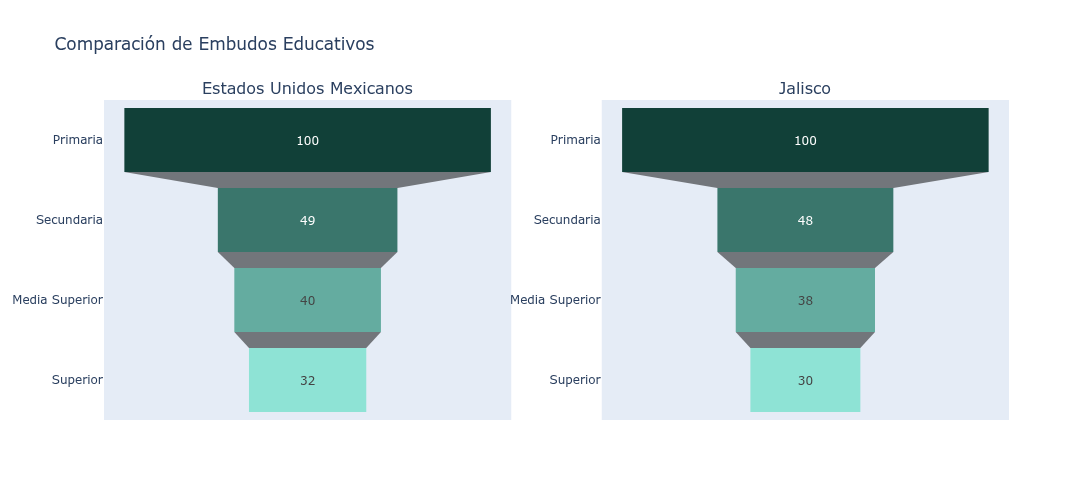

In [5]:
from plotly.subplots import make_subplots

def comparar_embudos(estado1, estado2):
    """Comparar embudos de dos estados"""
    
    fig = make_subplots(rows=1, cols=2, subplot_titles=[estado1, estado2])
    
    color_start = "#114038"
    color_end = "#8ee3d5"
    stages = ['Primaria', 'Secundaria', 'Media Superior', 'Superior']
    colors = [interpolate_color(color_start, color_end, i / 3) for i in range(4)]
    
    for col, estado in enumerate([estado1, estado2], 1):
        datos = matriculas[matriculas['Entidad federativa'] == estado].copy()
        datos = datos[datos['Nivel educativo'].isin(['Primaria', 'Secundaria', 'Media superior', 'Superior'])]
        orden = {'Primaria': 0, 'Secundaria': 1, 'Media superior': 2, 'Superior': 3}
        datos['orden'] = datos['Nivel educativo'].map(orden)
        datos = datos.sort_values('orden')
        
        total_primaria = datos['Total'].iloc[0]
        valores = [round((t / total_primaria) * 100) for t in datos['Total']]
        
        fig.add_trace(
            go.Funnel(
                y=stages, x=valores,
                marker=dict(color=colors),
                showlegend=False
            ),
            row=1, col=col
        )
    
    fig.update_layout(height=500, width=1000, title_text="Comparación de Embudos Educativos")
    return fig

# Comparar México con otro estado
fig_comp = comparar_embudos('Estados Unidos Mexicanos', 'Jalisco')
fig_comp.show()